In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from time import perf_counter

In [36]:
# Implement baseline algorithm
def baseline_max_sublist(arr):
    max_so_far = float('-inf')
    for i in range(len(arr)):
        current_max = 0      
        for j in range(i, len(arr)):
            current_max += arr[j]
            max_so_far = max(max_so_far, current_max)    
    return max_so_far

In [4]:
# Implement target algorithm
def kadane_max_sublist(arr):
    max_so_far = float('-inf')
    current_max = 0
    for i in range(len(arr)):
        current_max = current_max + arr[i]
        if current_max > max_so_far:
            max_so_far = current_max
        if current_max < 0:
            current_max = 0
    return max_so_far



In [48]:
arr = np.random.randint(-100, 100, size=10000)
baseline_max_sublist(arr)

np.int64(3609)

In [50]:
arr = np.random.randint(-100, 100, size=10000)
kadane_max_sublist(arr)

np.int64(6566)

In [41]:
baseline_time = []
for i in range(0,5):
    start_time = perf_counter()
    arr = np.random.randint(-100, 100, size=1000)
    baseline_max_sublist(arr)
    end_time = perf_counter()
    baseline_time.append(end_time - start_time)

avg_baseline_time = sum(baseline_time) / len(baseline_time)
print("Average baseline time of 5 runs:", avg_baseline_time)

kadane_time = []
for i in range(0,5):
    start_time = perf_counter()
    arr = np.random.randint(-100, 100, size=1000)
    kadane_max_sublist(arr)
    end_time = perf_counter()
    kadane_time.append(end_time - start_time)

avg_kadane_time = sum(kadane_time) / len(kadane_time)
print("Average Kadane's algorithm time of 5 runs:", avg_kadane_time)

start_time = perf_counter()
baseline_max_sublist([100, 500, 1000, 2500, 5000, 10000])
end_time = perf_counter()
print("Baseline times for baseline_max_sublist:", end_time - start_time)

start_time = perf_counter()
kadane_max_sublist([100, 500, 1000, 2500, 5000, 10000])
end_time = perf_counter()
print("Kadane's algorithm times for kadane_max_sublist:", end_time - start_time)

Average baseline time of 5 runs: 0.060595583399117456
Average Kadane's algorithm time of 5 runs: 0.00018934979889309033
Baseline times for baseline_max_sublist: 0.0001271660003112629
Kadane's algorithm times for kadane_max_sublist: 8.879199594957754e-05


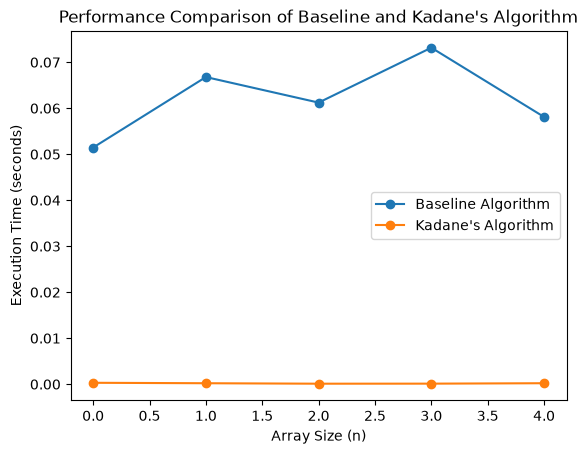

In [ ]:
# Plotting the results
# Create a line plot with Array Size (n) on the x-axis and Execution Time (seconds) on the y-axis.
import matplotlib.pyplot as plt

plt.plot(baseline_time, label='Baseline Algorithm', marker='o')
plt.plot(kadane_time, label='Kadane\'s Algorithm', marker='o')
plt.legend()
plt.xlabel('Array Size (n)')
# TODO: Figure out how to get the actual array sizes on the x-axis instead of just 0-4
plt.ylabel('Execution Time (seconds)')
plt.title('Performance Comparison of Baseline and Kadane\'s Algorithm')
plt.show()